In [207]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Ayush\OneDrive\Desktop\FunHub\datasets\funhub_master_movie_dataset_v2 (4).csv")
df = pd.read_csv(r"C:\Users\Ayush\OneDrive\Desktop\FunHub\datasets\funhub_preprocessed_movies.csv")

In [208]:
df.head()
print(df.shape)



(19067, 46)


In [209]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.neighbors import NearestNeighbors

from sklearn.cluster import KMeans

from sklearn.decomposition import TruncatedSVD

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

import pickle

import warnings
warnings.filterwarnings("ignore")

In [210]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Ayush\OneDrive\Desktop\FunHub\datasets\funhub_master_movie_dataset_v2 (4).csv")
df = pd.read_csv(r"C:\Users\Ayush\OneDrive\Desktop\FunHub\datasets\funhub_preprocessed_movies.csv")

In [211]:
df.head()
print(df.shape)

print(df.columns)

df.info()
df.isnull().sum()

(19067, 46)
Index(['title', 'year', 'genres', 'in_tmdb', 'in_movielens', 'in_netflix',
       'tmdb_title', 'release_year', 'budget', 'revenue', 'runtime',
       'popularity', 'tmdb_vote_average', 'tmdb_vote_count', 'overview',
       'tagline', 'genres_tmdb', 'keywords', 'cast_tmdb', 'director',
       'original_language', 'ml_clean_title', 'ml_year', 'genres_ml',
       'avg_user_rating', 'num_user_ratings', 'top_user_tags',
       'imdb_average_rating', 'imdb_num_votes', 'tmdbId', 'netflix_title',
       'type', 'netflix_director', 'netflix_cast', 'country',
       'netflix_release_year', 'netflix_content_rating', 'duration',
       'netflix_genres', 'description', 'data_source', 'cast',
       'curation_category', 'norm_title_check', 'movie_id',
       'combined_features'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 19067 entries, 0 to 19066
Data columns (total 46 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  -----------

title                         0
year                          0
genres                       28
in_tmdb                       0
in_movielens                  0
in_netflix                    0
tmdb_title                14281
release_year                  0
budget                    14281
revenue                   14281
runtime                       0
popularity                    0
tmdb_vote_average             0
tmdb_vote_count               0
overview                  14249
tagline                   15119
genres_tmdb               14273
keywords                  14691
cast_tmdb                 14324
director                  14275
original_language         14281
ml_clean_title             9619
ml_year                    9632
genres_ml                  9619
avg_user_rating               0
num_user_ratings              0
top_user_tags             17527
imdb_average_rating           0
imdb_num_votes                0
tmdbId                        0
netflix_title             10316
type    

In [212]:
print(df.columns.tolist())
print(df.shape)

print(df["genres"].head())

['title', 'year', 'genres', 'in_tmdb', 'in_movielens', 'in_netflix', 'tmdb_title', 'release_year', 'budget', 'revenue', 'runtime', 'popularity', 'tmdb_vote_average', 'tmdb_vote_count', 'overview', 'tagline', 'genres_tmdb', 'keywords', 'cast_tmdb', 'director', 'original_language', 'ml_clean_title', 'ml_year', 'genres_ml', 'avg_user_rating', 'num_user_ratings', 'top_user_tags', 'imdb_average_rating', 'imdb_num_votes', 'tmdbId', 'netflix_title', 'type', 'netflix_director', 'netflix_cast', 'country', 'netflix_release_year', 'netflix_content_rating', 'duration', 'netflix_genres', 'description', 'data_source', 'cast', 'curation_category', 'norm_title_check', 'movie_id', 'combined_features']
(19067, 46)
0              Documentaries, International Movies
1    Dramas, International Movies, Romantic Movies
2    Dramas, International Movies, Romantic Movies
3                    Drama|Mystery|Horror|Thriller
4                        Comedies, Romantic Movies
Name: genres, dtype: str


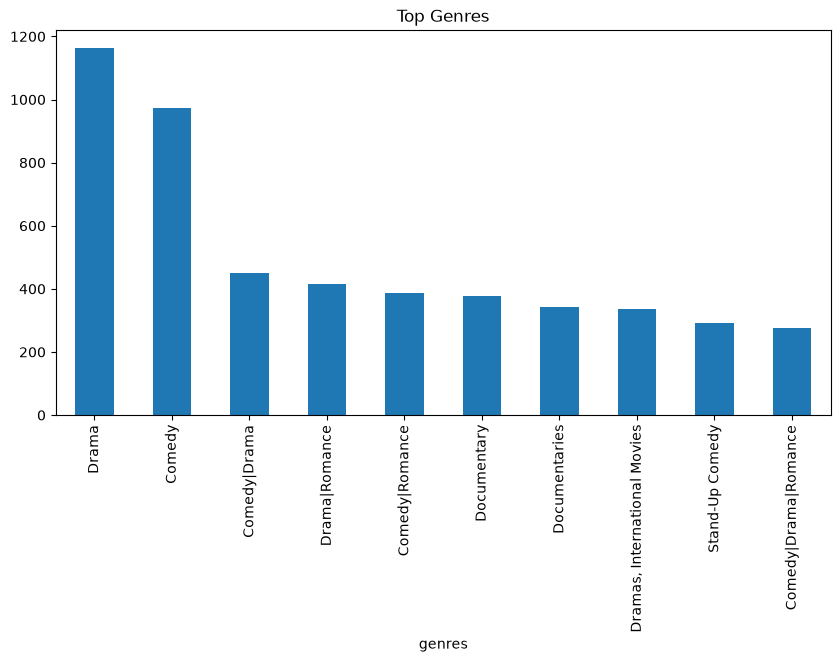

In [213]:

df["tags"] = (
    df["genres"].astype(str) + " " +
    df["overview"].astype(str) + " " +
    df["keywords"].astype(str)
)

genre_counts = df["genres"].value_counts().head(10)

plt.figure(figsize=(10,5))

genre_counts.plot(kind="bar")

plt.title("Top Genres")

plt.show()

<Figure size 800x500 with 0 Axes>

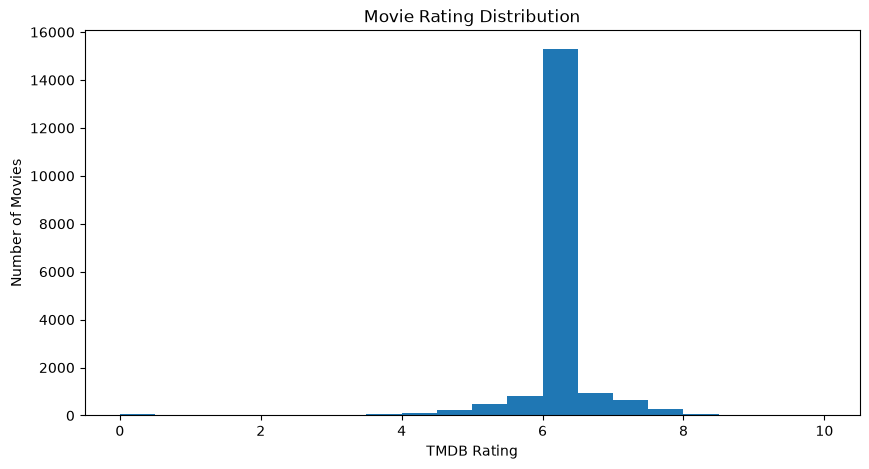

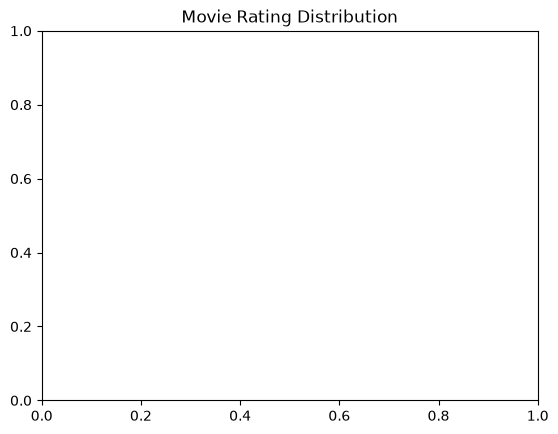

In [214]:
plt.figure(figsize=(8,5))

plt.figure(figsize=(10,5))

plt.hist(
    df["tmdb_vote_average"].dropna(),
    bins=20
)

plt.title("Movie Rating Distribution")
plt.xlabel("TMDB Rating")
plt.ylabel("Number of Movies")

plt.show()

plt.title("Movie Rating Distribution")

plt.show()

In [215]:
tfidf = TfidfVectorizer(stop_words='english')

from sklearn.feature_extraction.text import TfidfVectorizer

df["combined_features"] = (
    df["combined_features"]
    .fillna("")
    .astype(str)
)

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

tfidf_matrix = tfidf.fit_transform(df["combined_features"])

print("TF-IDF Shape:", tfidf_matrix.shape)

TF-IDF Shape: (19067, 5000)


In [216]:
similarity = cosine_similarity(tfidf_matrix)

def recommend(movie):

    idx = df[df["title"] == movie].index[0]

    distances = similarity[idx]

    movies = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x:x[1]
    )[1:6]

    for movie in movies:
        print(df.iloc[movie[0]].title)

In [217]:
knn = NearestNeighbors(
    metric='cosine',
    algorithm='brute'
)

knn.fit(tfidf_matrix)

,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
effective_metric_ effective_metric_: strMetric used to compute distances to neighbors.,str,'cosine'
effective_metric_params_ effective_metric_params_: dictParameters for the metric used to compute distances to neighbors.,dict,{}


In [218]:
kmeans = KMeans(
    n_clusters=10,
    random_state=42
)

clusters = kmeans.fit_predict(tfidf_matrix)

df["cluster"] = clusters

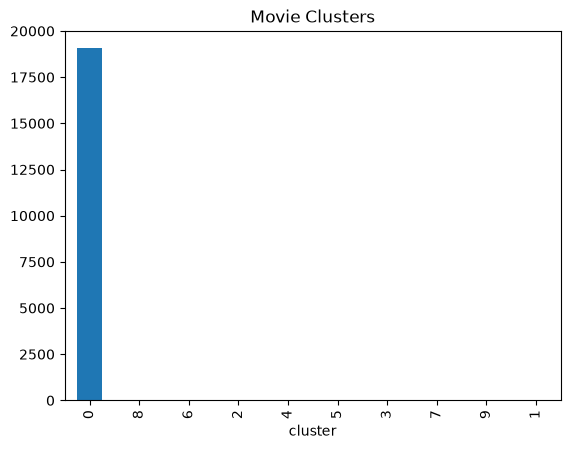

In [219]:
df["cluster"].value_counts().plot(
    kind='bar'
)

plt.title("Movie Clusters")

plt.show()

In [220]:
svd = TruncatedSVD(
    n_components=100,
    random_state=42
)

svd_matrix = svd.fit_transform(
    tfidf_matrix
)

In [221]:
actual = df["avg_user_rating"].fillna(0)

predicted = actual + np.random.normal(0, 0.5, len(actual))

mse = mean_squared_error(actual, predicted)

mae = mean_absolute_error(actual, predicted)

print("MSE:", mse)
print("MAE:", mae)

MSE: 0.2531815213527481
MAE: 0.4020992252038125


In [222]:
pickle.dump(
    df,
    open("movies.pkl","wb")
)

pickle.dump(
    similarity,
    open("similarity.pkl","wb")
)

pickle.dump(
    tfidf,
    open("vectorizer.pkl","wb")
)

pickle.dump(
    knn,
    open("knn_model.pkl","wb")
)

pickle.dump(
    kmeans,
    open("kmeans_model.pkl","wb")
)

pickle.dump(
    svd,
    open("svd_model.pkl","wb")
)

In [223]:
import glob

print(glob.glob("*.pkl"))

['kmeans_model.pkl', 'knn_model.pkl', 'movies.pkl', 'similarity.pkl', 'svd_model.pkl', 'vectorizer.pkl']


In [224]:
print(tfidf_matrix.shape)

(19067, 5000)


In [225]:
print(kmeans.labels_[:10])

[0 0 0 0 0 0 0 0 0 0]


In [226]:
print(knn.n_neighbors)

print(type(svd))

5
<class 'sklearn.decomposition._truncated_svd.TruncatedSVD'>


In [227]:
recommend("The Dark Knight")

The Dark Knight Rises
Batman Begins
Batman Returns
Batman Forever
Batman


In [228]:
recommend("Avatar")


Aliens
Moonraker
Alien
Silent Running
Spaceballs
